In [10]:
import os
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("andreazzini/international-airline-passengers")
file_path = os.path.join(path, os.listdir(path)[0])

df = pd.read_csv(file_path)

# keep first 2 cols only, rename
df = df.iloc[:, :2]
df.columns = ["Month", "Passengers"]

# clean bad rows (footer text)
df["Month"] = pd.to_datetime(df["Month"], errors="coerce")
df["Passengers"] = pd.to_numeric(df["Passengers"], errors="coerce")
df = df.dropna(subset=["Month", "Passengers"]).set_index("Month").sort_index()

df.head(), df.tail()


Using Colab cache for faster access to the 'international-airline-passengers' dataset.


(            Passengers
 Month                 
 1949-01-01       112.0
 1949-02-01       118.0
 1949-03-01       132.0
 1949-04-01       129.0
 1949-05-01       121.0,
             Passengers
 Month                 
 1960-08-01       606.0
 1960-09-01       508.0
 1960-10-01       461.0
 1960-11-01       390.0
 1960-12-01       432.0)

In [11]:
train = df.loc[: "1959-12-01", "Passengers"]
test  = df.loc["1960-01-01":"1960-12-01", "Passengers"]

print(train.index.min(), train.index.max(), len(train))
print(test.index.min(), test.index.max(), len(test))


1949-01-01 00:00:00 1959-12-01 00:00:00 132
1960-01-01 00:00:00 1960-12-01 00:00:00 12


In [12]:
import time
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

best = {"order": None, "aic": np.inf}

# Reasonable search ranges for this classic dataset
p_range = range(0, 6)
d_range = range(0, 3)
q_range = range(0, 6)

t0 = time.perf_counter()

for p in p_range:
    for d in d_range:
        for q in q_range:
            try:
                model = ARIMA(train, order=(p,d,q))
                res = model.fit()
                if res.aic < best["aic"]:
                    best = {"order": (p,d,q), "aic": res.aic}
            except:
                pass

# Fit best model + forecast
best_order = best["order"]
arima_fit = ARIMA(train, order=best_order).fit()
arima_forecast = arima_fit.forecast(steps=12)

t1 = time.perf_counter()
arima_runtime = t1 - t0

arima_rmse = rmse(test.values, arima_forecast.values)
arima_mae  = mean_absolute_error(test.values, arima_forecast.values)

best_order, best["aic"], arima_rmse, arima_mae, arima_runtime


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

((5, 1, 5),
 np.float64(1205.055590659766),
 np.float64(54.43986851487983),
 45.46627632152354,
 58.266749680999965)

In [14]:
from xgboost import XGBRegressor

def make_lag_features(series, lags=12):
    df_feat = pd.DataFrame({"y": series})
    for lag in range(1, lags+1):
        df_feat[f"lag_{lag}"] = df_feat["y"].shift(lag)
    df_feat["month"] = df_feat.index.month
    return df_feat.dropna()

lags = 12
feat_all = make_lag_features(df["Passengers"], lags=lags)

X_train = feat_all.loc[: "1959-12-01"].drop(columns=["y"])
y_train = feat_all.loc[: "1959-12-01"]["y"]

X_test  = feat_all.loc["1960-01-01":"1960-12-01"].drop(columns=["y"])
y_test  = feat_all.loc["1960-01-01":"1960-12-01"]["y"]

t0 = time.perf_counter()

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

t1 = time.perf_counter()
xgb_runtime = t1 - t0

xgb_rmse = rmse(y_test.values, xgb_pred)
xgb_mae  = mean_absolute_error(y_test.values, xgb_pred)

xgb_rmse, xgb_mae, xgb_runtime


(np.float64(37.86555099856474), 29.35425313313802, 1.375890647999995)

In [15]:
results = pd.DataFrame({
    "Model": ["ARIMA", "XGBoost"],
    "RMSE": [arima_rmse, xgb_rmse],
    "MAE":  [arima_mae,  xgb_mae],
    "Runtime_sec": [arima_runtime, xgb_runtime],
})

results


,Model,RMSE,MAE,Runtime_sec
0,ARIMA,54.439869,45.466276,58.266750
1,XGBoost,37.865551,29.354253,1.375891


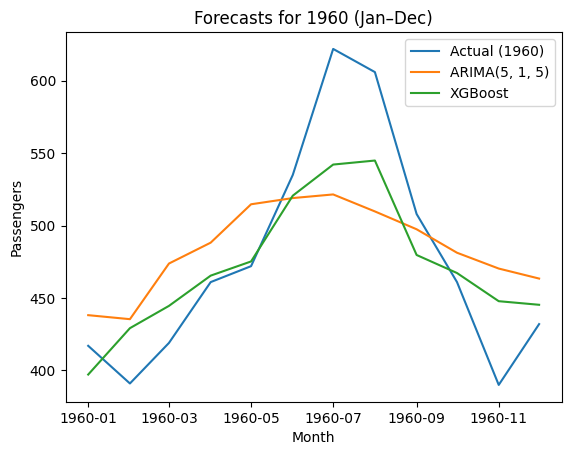

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(test.index, test.values, label="Actual (1960)")
plt.plot(test.index, arima_forecast.values, label=f"ARIMA{best_order}")
plt.plot(test.index, xgb_pred, label="XGBoost")
plt.title("Forecasts for 1960 (Jan–Dec)")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()


The ARIMA(5,1,5) model was used to forecast passenger numbers for January–December 1960. It was able to follow the overall upward trend of the data, but it underestimated the strong peak during the middle of the year. ARIMA produced an RMSE of 54.44 and an MAE of 45.47, with a runtime of 58.27 seconds.

The XGBoost model performed better overall. It captured the seasonal pattern more closely and gave more accurate predictions, especially around the mid-year increase. XGBoost achieved a lower RMSE of 37.87 and MAE of 29.35, and it ran much faster at only 1.38 seconds.

Overall, XGBoost outperformed ARIMA in both accuracy and speed for this dataset.